Titulo: Mantenimiento Predictivo con Machine Learning
Introducción: Para la realización de este pequeño proyecto tomé el conjunto de datos de mantenimiento predictivo(AI4I 2020) link del dataset(https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020?select=ai4i2020.csv) que es conjunto de datos de una fresadora existente y consta de 10 000 puntos de datos almacenados en filas con 14 características en columnas.

In [17]:
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
#!pip install imbalanced-learn

In [19]:
path = kagglehub.dataset_download(
    "stephanmatzka/predictive-maintenance-dataset-ai4i-2020"
)

In [4]:
print(path)


C:\Users\Usuario\.cache\kagglehub\datasets\stephanmatzka\predictive-maintenance-dataset-ai4i-2020\versions\2


In [5]:
csv_path = os.path.join(path, "ai4i2020.csv")
df = pd.read_csv(csv_path)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
eliminar_columnas = ['UDI', 'Product ID', 'TWF', 'HDF',	'PWF', 'OSF', 'RNF']


In [7]:
df = df.drop(columns=eliminar_columnas)

In [8]:
df = pd.get_dummies(df, columns=['Type'], drop_first=True)

In [10]:
#División y balanceo de datos
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [11]:
X = df.drop(columns=['Machine failure'])
y = df['Machine failure']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
stratify=y)

print(f"Dimensiones originales de Train: {X_train.shape}")
print(f"Conteo de fallos en Train antes de SMOTE:\n{y_train.value_counts()}")

Dimensiones originales de Train: (8000, 7)
Conteo de fallos en Train antes de SMOTE:
Machine failure
0    7729
1     271
Name: count, dtype: int64


In [12]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\n--- APLICANDO SMOTE ---")
print(f"Dimensiones de Train después de SMOTE: {X_train_resampled.shape}")
print(f"Conteo de fallos en Train después de SMOTE:\n{y_train_resampled.value_counts()}")


--- APLICANDO SMOTE ---
Dimensiones de Train después de SMOTE: (15458, 7)
Conteo de fallos en Train después de SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [13]:
# Entrenar modelo: Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred = rf_model.predict(X_test)
print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(y_test, y_pred))

--- MATRIZ DE CONFUSIÓN ---
[[1876   56]
 [  19   49]]


In [14]:
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.47      0.72      0.57        68

    accuracy                           0.96      2000
   macro avg       0.73      0.85      0.77      2000
weighted avg       0.97      0.96      0.97      2000



In [24]:
importances = rf_model.feature_importances_
feature_names = X.columns

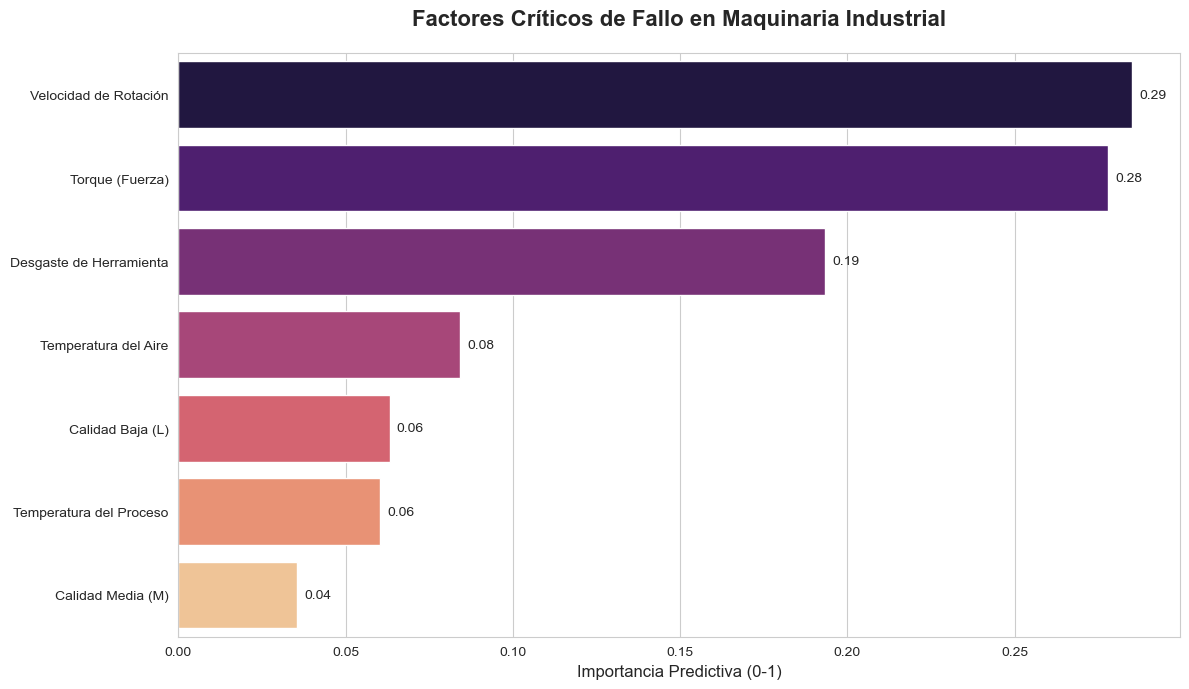

In [25]:
# Grafico
nombres_espanol = {
    'Torque [Nm]': 'Torque (Fuerza)',
    'Rotational speed [rpm]': 'Velocidad de Rotación',
    'Tool wear [min]': 'Desgaste de Herramienta',
    'Air temperature [K]': 'Temperatura del Aire',
    'Process temperature [K]': 'Temperatura del Proceso',
    'Temp_diff': 'Diferencia Térmica',
    'Type_L': 'Calidad Baja (L)',
    'Type_M': 'Calidad Media (M)'
}

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


feature_importance_df['Feature'] = feature_importance_df['Feature'].map(nombres_espanol)


plt.figure(figsize=(12, 7))
sns.set_style("whitegrid") 


ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='magma', 
    hue='Feature', 
    legend=False
)

# Títulos y etiquetas
plt.title('Factores Críticos de Fallo en Maquinaria Industrial', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importancia Predictiva (0-1)', fontsize=12)
plt.ylabel('', fontsize=12)

# El valor numérico al final de cada barra 
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=5)

plt.tight_layout()
plt.show()